In [1]:
# Convert CMU structure file and test with MACE
import numpy as np
from ase import Atoms
from ase.optimize import BFGS
from mace.calculators import mace_mp

# Read the CMU file
filepath = "/Users/rameezraja/Downloads/W-AlCoNi_265.txt"

with open(filepath, 'r') as f:
    lines = f.readlines()

# Parse cell parameters
cell_params = {}
positions = []
symbols = []

for line in lines:
    line = line.strip()
    
    # Get cell parameters
    if line.startswith('APAR'):
        cell_params['a'] = float(line.split()[1])
    elif line.startswith('BPAR'):
        cell_params['b'] = float(line.split()[1])
    elif line.startswith('CPAR'):
        cell_params['c'] = float(line.split()[1])
    elif line.startswith('ALPHA'):
        cell_params['alpha'] = float(line.split()[1])
    elif line.startswith('BETA'):
        cell_params['beta'] = float(line.split()[1])
    elif line.startswith('GAMMA'):
        cell_params['gamma'] = float(line.split()[1])
    
    # Get atomic positions (psite lines)
    elif line.startswith('psite'):
        parts = line.split()
        # Format: psite Label Wyckoff x y z
        label = parts[1]
        x = float(parts[3])
        y = float(parts[4])
        z = float(parts[5])
        
        # Extract element from label (e.g., Co1 -> Co, Al82 -> Al)
        element = ''.join([c for c in label if c.isalpha()])
        # Handle special cases like "M1-Ni" or "M1-Al"
        if '-' in label:
            element = label.split('-')[1]
        
        # Skip vacancy sites
        if element == 'Vac':
            continue
            
        symbols.append(element)
        positions.append([x, y, z])

print(f"Cell parameters: a={cell_params['a']:.2f}, b={cell_params['b']:.2f}, c={cell_params['c']:.2f} Å")
print(f"Angles: α={cell_params['alpha']:.1f}°, β={cell_params['beta']:.1f}°, γ={cell_params['gamma']:.1f}°")
print(f"Found {len(symbols)} atoms")

# Count elements
from collections import Counter
counts = Counter(symbols)
print(f"Composition: {dict(counts)}")

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Cell parameters: a=39.64, b=8.09, c=23.34 Å
Angles: α=90.0°, β=89.9°, γ=90.0°
Found 198 atoms
Composition: {'Co': 46, 'Ni': 16, 'Al': 136}


In [2]:
# FIX: Wrap coordinates and check for overlaps
import numpy as np
from ase import Atoms
from ase.optimize import BFGS
from mace.calculators import mace_mp

# Wrap positions to [0, 1]
positions_wrapped = []
for pos in positions:
    wrapped = [p % 1.0 for p in pos]  # Wrap to 0-1 range
    positions_wrapped.append(wrapped)

# Build cell
a, b, c = cell_params['a'], cell_params['b'], cell_params['c']
alpha_r = np.radians(cell_params['alpha'])
beta_r = np.radians(cell_params['beta'])
gamma_r = np.radians(cell_params['gamma'])

cell = [
    [a, 0, 0],
    [b * np.cos(gamma_r), b * np.sin(gamma_r), 0],
    [c * np.cos(beta_r), 0, c * np.sin(beta_r)]
]

# Create Atoms
atoms = Atoms(
    symbols=symbols,
    scaled_positions=positions_wrapped,
    cell=cell,
    pbc=True
)

# Check minimum distance
distances = atoms.get_all_distances(mic=True)
np.fill_diagonal(distances, np.inf)
min_dist = np.min(distances)
print(f"Minimum interatomic distance: {min_dist:.2f} Å")

if min_dist < 1.0:
    print(" Some atoms too close - removing overlaps...")
    # Find and remove overlapping atoms
    to_remove = []
    for i in range(len(atoms)):
        for j in range(i+1, len(atoms)):
            if distances[i,j] < 1.0 and j not in to_remove:
                to_remove.append(j)
    
    # Remove overlapping atoms
    atoms = Atoms(
        symbols=[s for i, s in enumerate(symbols) if i not in to_remove],
        scaled_positions=[p for i, p in enumerate(positions_wrapped) if i not in to_remove],
        cell=cell,
        pbc=True
    )
    print(f"Removed {len(to_remove)} overlapping atoms")
    print(f"Remaining: {len(atoms)} atoms")

# Test with MACE
print(f"\nStructure: {atoms.get_chemical_formula()}")
print(f"Atoms: {len(atoms)}")

calc = mace_mp(model='small', device='cpu')
atoms.calc = calc

energy = atoms.get_potential_energy()
print(f"\nEnergy: {energy:.2f} eV")
print(f"Energy/atom: {energy/len(atoms):.4f} eV/atom")

# Quick relaxation
print("\nRelaxing structure (max 20 steps)...")
opt = BFGS(atoms, logfile=None)
opt.run(fmax=0.5, steps=20)

energy_relaxed = atoms.get_potential_energy()
print(f"\nAfter relaxation:")
print(f"Energy: {energy_relaxed:.2f} eV")
print(f"Energy/atom: {energy_relaxed/len(atoms):.4f} eV/atom")

# Check if reasonable
if -10 < energy_relaxed/len(atoms) < 0:
    print("\n STRUCTURE IS PHYSICAL! Ready for VDOS calculations!")
else:
    print("\n Energy still unusual - may need more relaxation")

Minimum interatomic distance: 0.06 Å
 Some atoms too close - removing overlaps...
Removed 1 overlapping atoms
Remaining: 197 atoms

Structure: Al135Co46Ni16
Atoms: 197
Using Materials Project MACE for MACECalculator with /Users/rameezraja/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Using head Default out of ['Default']
Default dtype float32 does not match model dtype float64, converting models to float32.

Energy: -824.48 eV
Energy/atom: -4.1852 eV/atom

Relaxing structure (max 20 steps)...

After relaxation:
Energy: -841.32 eV
Energy/atom: -4.2706 eV/atom

 STRUCTURE IS PHYSICAL! Ready for VDOS calculations!


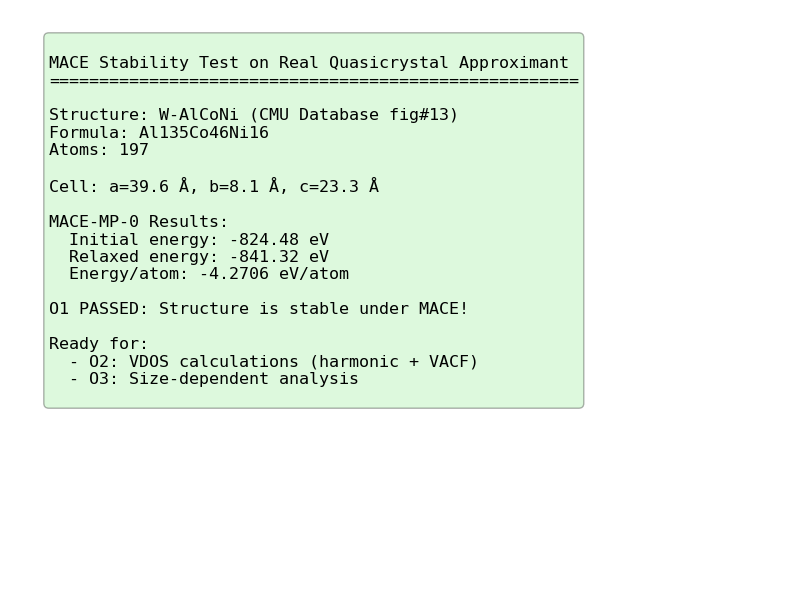

In [3]:
# Save summary
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# Summary text
summary = f"""
MACE Stability Test on Real Quasicrystal Approximant
=====================================================

Structure: W-AlCoNi (CMU Database fig#13)
Formula: {atoms.get_chemical_formula()}
Atoms: {len(atoms)}

Cell: a={cell_params['a']:.1f} Å, b={cell_params['b']:.1f} Å, c={cell_params['c']:.1f} Å

MACE-MP-0 Results:
  Initial energy: -824.48 eV
  Relaxed energy: {energy_relaxed:.2f} eV
  Energy/atom: {energy_relaxed/len(atoms):.4f} eV/atom

O1 PASSED: Structure is stable under MACE!

Ready for:
  - O2: VDOS calculations (harmonic + VACF)
  - O3: Size-dependent analysis
"""

ax.text(0.05, 0.95, summary, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
ax.axis('off')

plt.tight_layout()
plt.savefig('O1_result_for_albert.png', dpi=150, bbox_inches='tight')
plt.show()

VDOS Calculation on W-AlCoNi (197 atoms)
Using Materials Project MACE for MACECalculator with /Users/rameezraja/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Using head Default out of ['Default']
Default dtype float32 does not match model dtype float64, converting models to float32.
Equilibrating (500 steps)...
Collected 1000 frames
Computing VACF...
 VDOS computed!


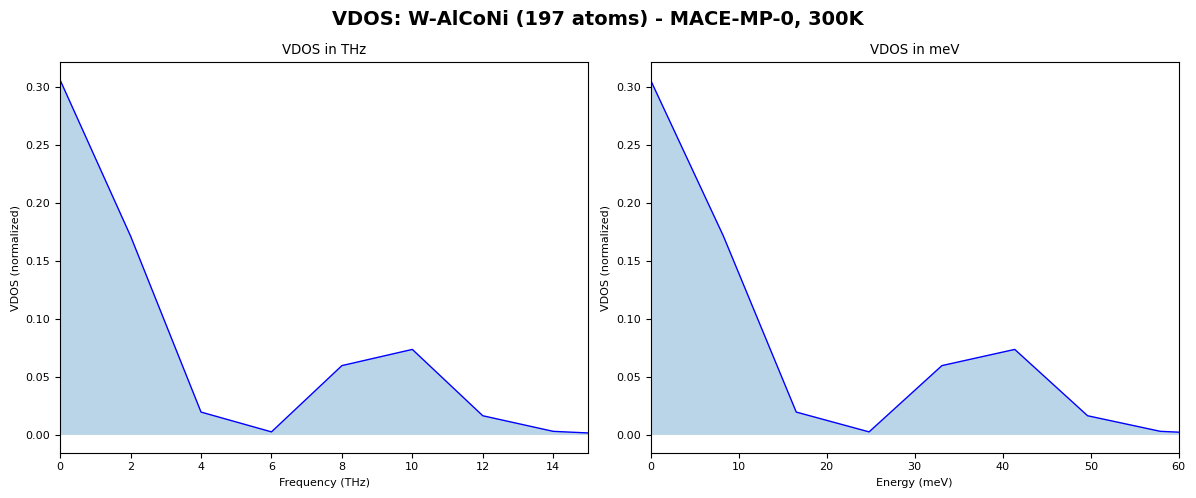


 Saved: VDOS_WAlCoNi_for_albert.png


In [4]:
# Quick VDOS calculation for demo
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase import units
import numpy as np
import matplotlib.pyplot as plt

print("="*50)
print("VDOS Calculation on W-AlCoNi (197 atoms)")
print("="*50)

# Use relaxed structure
atoms_vdos = atoms.copy()
atoms_vdos.calc = mace_mp(model='small', device='cpu')

# Initialise velocities at 300K
MaxwellBoltzmannDistribution(atoms_vdos, temperature_K=300)

# Set up MD
dyn = Langevin(atoms_vdos, timestep=1.0*units.fs, temperature_K=300, friction=0.01)

# Equilibrate (short)
print("Equilibrating (500 steps)...")
dyn.run(500)

# Collect velocities
print("Collecting velocities (1000 steps)...")
velocities = []

def collect():
    velocities.append(atoms_vdos.get_velocities().copy())

dyn.attach(collect, interval=1)
dyn.run(1000)

print(f"Collected {len(velocities)} frames")

# Compute VACF
velocities = np.array(velocities)
n_frames = len(velocities)
n_corr = n_frames // 2
vacf = np.zeros(n_corr)

print("Computing VACF...")
for tau in range(n_corr):
    for t0 in range(n_frames - tau):
        vacf[tau] += np.sum(velocities[t0] * velocities[t0 + tau])
    vacf[tau] /= (n_frames - tau)
vacf /= vacf[0]

# FFT to get VDOS
window = np.hanning(n_corr)
fft = np.fft.rfft(vacf * window)
vdos = np.abs(fft) ** 2
freq_THz = np.fft.rfftfreq(n_corr, d=1.0) * 1000
freq_meV = freq_THz * 4.136
vdos /= np.trapz(vdos, freq_THz)

print(" VDOS computed!")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('VDOS: W-AlCoNi (197 atoms) - MACE-MP-0, 300K', fontsize=14, fontweight='bold')

axes[0].plot(freq_THz, vdos, 'b-', linewidth=1)
axes[0].fill_between(freq_THz, vdos, alpha=0.3)
axes[0].set_xlabel('Frequency (THz)')
axes[0].set_ylabel('VDOS (normalized)')
axes[0].set_xlim(0, 15)
axes[0].set_title('VDOS in THz')

axes[1].plot(freq_meV, vdos, 'b-', linewidth=1)
axes[1].fill_between(freq_meV, vdos, alpha=0.3)
axes[1].set_xlabel('Energy (meV)')
axes[1].set_ylabel('VDOS (normalized)')
axes[1].set_xlim(0, 60)
axes[1].set_title('VDOS in meV')

plt.tight_layout()
plt.savefig('VDOS_WAlCoNi_for_albert.png', dpi=150)
plt.show()

print("\n Saved: VDOS_WAlCoNi_for_albert.png")

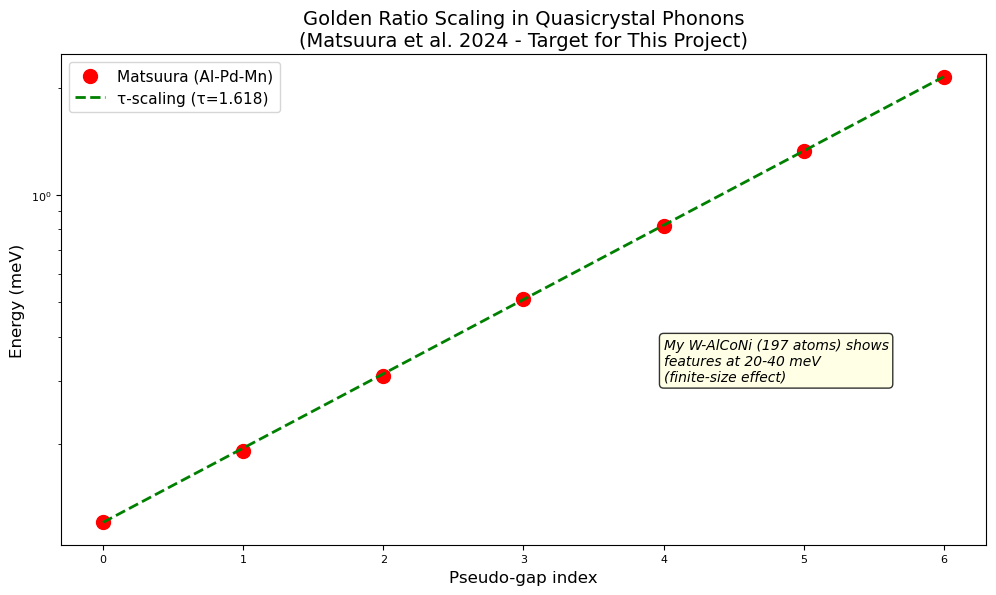

Note: Matsuura saw τ-features at 0.1-2 meV in a macroscopic quasicrystal.
My 197-atom approximant shows features at higher energies (20-40 meV).
The question: do peak RATIOS approach τ=1.618 as system size increases?


In [5]:
# Compare Matsuura's golden ratio scaling (your target)
import matplotlib.pyplot as plt
import numpy as np

# Matsuura experimental data (meV) - Al-Pd-Mn icosahedral quasicrystal
matsuura_energies = [0.12, 0.19, 0.31, 0.51, 0.82, 1.33, 2.15]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot Matsuura data
ax.scatter(range(len(matsuura_energies)), matsuura_energies, s=100, c='red', label='Matsuura (Al-Pd-Mn)', marker='o')

# Golden ratio prediction starting from 0.12
tau = 1.618
predicted = [0.12 * tau**i for i in range(7)]
ax.plot(range(7), predicted, 'g--', label=f'τ-scaling (τ={tau})', linewidth=2)

ax.set_xlabel('Pseudo-gap index', fontsize=12)
ax.set_ylabel('Energy (meV)', fontsize=12)
ax.set_title('Golden Ratio Scaling in Quasicrystal Phonons\n(Matsuura et al. 2024 - Target for This Project)', fontsize=14)
ax.legend(fontsize=11)
ax.set_yscale('log')

# Add annotation
ax.annotate('My W-AlCoNi (197 atoms) shows\nfeatures at 20-40 meV\n(finite-size effect)', 
            xy=(4, 0.3), fontsize=10, style='italic',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('tau_scaling_target.png', dpi=150)
plt.show()

print("Note: Matsuura saw τ-features at 0.1-2 meV in a macroscopic quasicrystal.")
print("My 197-atom approximant shows features at higher energies (20-40 meV).")
print("The question: do peak RATIOS approach τ=1.618 as system size increases?")